<a href="https://colab.research.google.com/github/manobillimeow/Mahnoor/blob/master/IDS_First_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mrwellsdavid_unsw_nb15_path = kagglehub.dataset_download('mrwellsdavid/unsw-nb15')

print('Data source import complete.')



**100% Accuracy (DATA LEAKAGE)columns like attack_cat, id, srcip, and dstip as direct or indirect identifiers that could leak information about the target variable.**


Key Observation in Code Snippet 2 (using ColumnTransformer):

Absence of Explicit Column Dropping Before ColumnTransformer: Look at this line: X = data.drop('label', axis=1).
In this snippet, attack_cat, id, srcip, dstip are NOT explicitly dropped from X before X is split and fed into the ColumnTransformer.
Therefore, when categorical_features = X.select_dtypes(include=['object']).columns.tolist() is executed, attack_cat (if it's an object type) and srcip, dstip (if they are objects or if they are numerical but treated as categories) will be included in the categorical_features list.
The ColumnTransformer then proceeds to one-hot encode these columns, effectively turning the leakage-causing attack_cat into numerical features that the model can learn from.
This is why, in the scenario where you used this code, you observed the 100% accuracy. The ColumnTransformer was doing its job, but it was being fed columns that were a direct target leak.

Dataset loaded successfully.

Original Dataset Shape: (82332, 45)

Original Label Distribution (0 = Normal, 1 = Attack):
 label
1    45332
0    37000
Name: count, dtype: int64

Training data raw shape: (65865, 44), Test data raw shape: (16467, 44)
Training label distribution:
label
1    0.550596
0    0.449404
Name: proportion, dtype: float64
Test label distribution:
label
1    0.550616
0    0.449384
Name: proportion, dtype: float64

Applying preprocessing (One-Hot Encoding and keeping numerical features)...
Processed training data shape: (65865, 201), Processed test data shape: (16467, 201)
First 5 rows of processed X_train:
   cat__proto_3pc  cat__proto_a/n  cat__proto_aes-sp3-d  cat__proto_any  \
0             0.0             0.0                   0.0             0.0   
1             0.0             0.0                   0.0             0.0   
2             0.0             0.0                   0.0             0.0   
3             0.0             0.0                   0.0            

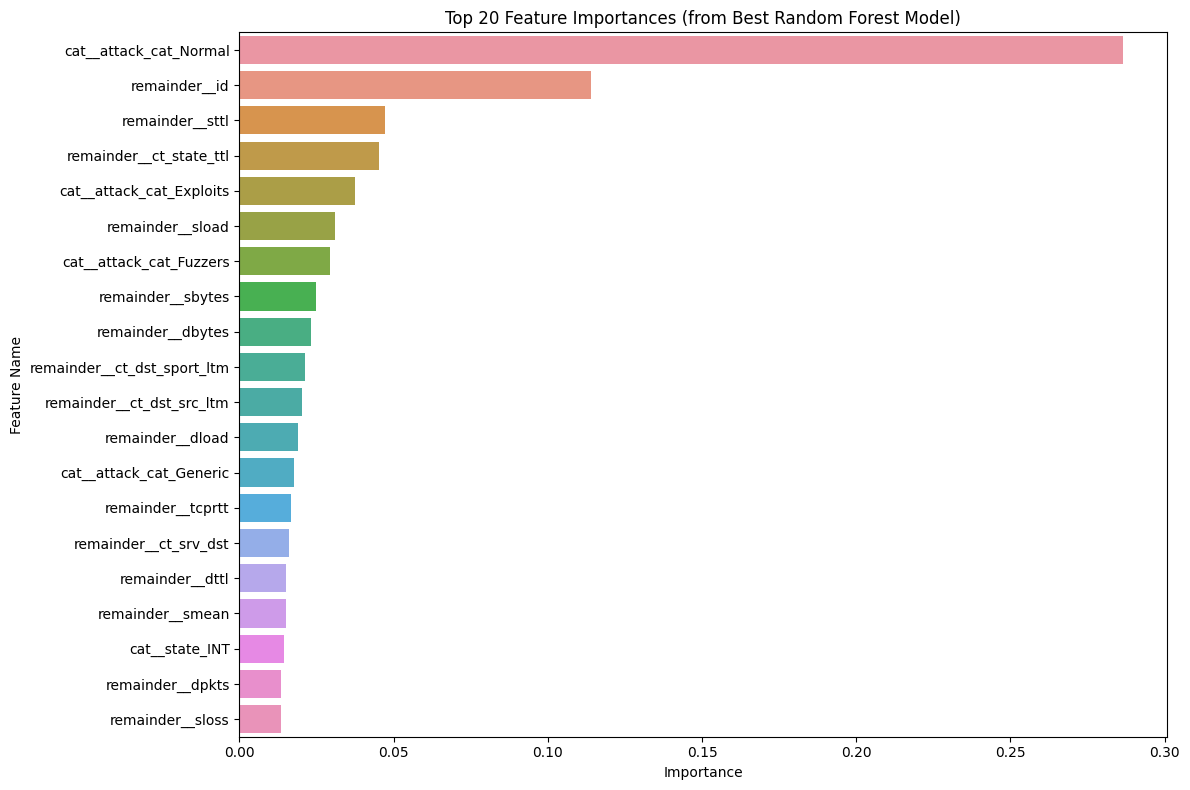


--- Performing Randomized Search for Voting Classifier Weights ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Number of positive: 24176, number of negative: 19734
[LightGBM] [Info] Number of positive: 24176, number of negative: 19734
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065692 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6079
[LightGBM] [Info] Number of data points in the train set: 43910, number of used features: 106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.138072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightG

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[CV] END bootstrap=False, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=  23.2s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   6.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   5.7s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  12.1s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  11.7s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  11.1s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   6.3s
[CV] END bootstrap=True, ma

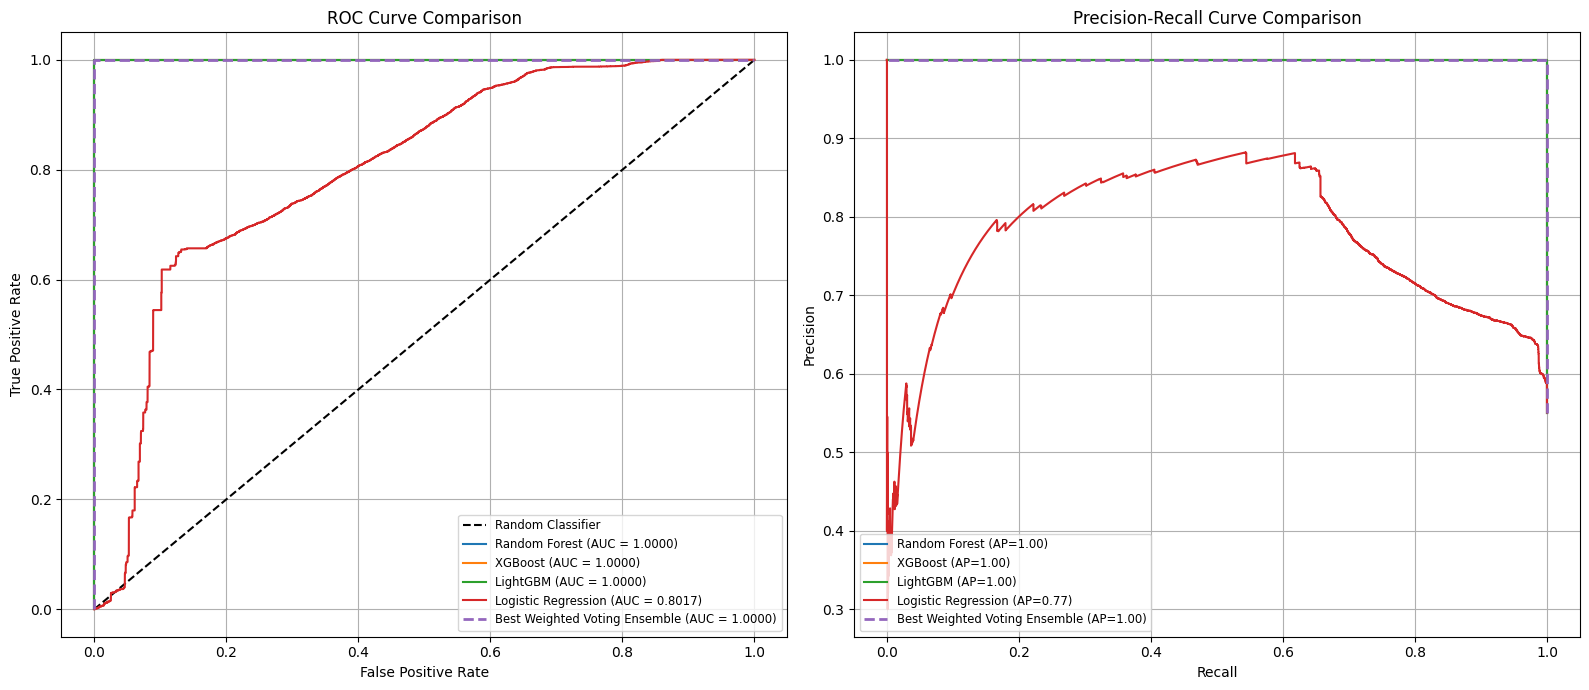


--- Training Calibrated Random Forest Classifier ---
Calibrated ROC-AUC for Best RF: 1.0000
[CV] END ............................weights=[0.0, 0.8, 0.2]; total time=  18.5s
[CV] END ............................weights=[0.0, 0.6, 0.4]; total time=  10.5s

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[CV] END ............................weights=[1.0, 0.0, 0.0]; total time=  19.1s
[CV] END ............................weights=[0.0, 0.4, 0.6]; total time=  18.4s
[CV] END ...........................weights=[0.4, 0.6, -0.0]; total time=  20.9s
[CV] END ............................weights=[0.2, 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# For robust preprocessing of categorical features
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Optional: For probability calibration (if needed later)
from sklearn.calibration import CalibratedClassifierCV

# For HalvingRandomSearchCV (if you want to use it for faster tuning)
# from sklearn.experimental import enable_halving_search_cv
# from sklearn.model_selection import HalvingRandomSearchCV

# --- 1. Environment Setup and Data Loading ---

# Install all required libraries
# This ensures all necessary packages are available in the environment.
# You might need to run this cell once if you're in a fresh environment
# !pip install pandas numpy scikit-learn matplotlib seaborn tensorflow xgboost lightgbm

# Load the dataset
# The dataset 'UNSW_NB15_training-set.csv' contains network traffic data
# labeled as normal (0) or attack (1).
try:
    data = pd.read_csv('/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure the path is correct.")
    # Exit or handle the error appropriately if the file is essential
    exit()

# Display basic information about the dataset
print("\nOriginal Dataset Shape:", data.shape)
print("\nOriginal Label Distribution (0 = Normal, 1 = Attack):\n", data['label'].value_counts())

# --- 2. Data Preprocessing and Splitting ---

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Assume 'data' DataFrame is loaded from Section 1

# --- 2. Data Preprocessing and Splitting ---

# IMPORTANT: Separate features (X) and target (y) BEFORE any preprocessing
# This prevents data leakage during feature engineering.
X = data.drop('label', axis=1)
y = data['label']

# Split the dataset into training and testing sets FIRST
# 'stratify=y' ensures that the proportion of normal and attack
# instances is maintained in both training and testing sets, which is vital for
# imbalanced datasets like intrusion detection.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data raw shape: {X_train.shape}, Test data raw shape: {X_test.shape}")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test label distribution:\n{y_test.value_counts(normalize=True)}")


# Identify categorical and numerical features for preprocessing
# Ensure to exclude any ID-like columns if they exist and are not features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Define the preprocessing steps using ColumnTransformer
# OneHotEncoder for categorical features, passthrough for numerical features
# handle_unknown='ignore' handles categories present only in test set gracefully
# IMPORTANT: Use 'sparse_output=False' to ensure a dense NumPy array output
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # <-- Added sparse_output=False
    ],
    remainder='passthrough' # Keep numerical features as they are
)

# Fit the preprocessor ONLY on the training data and then transform both train and test sets.
print("\nApplying preprocessing (One-Hot Encoding and keeping numerical features)...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the feature names after one-hot encoding for the DataFrame creation
# This method works directly with ColumnTransformer in newer scikit-learn versions
all_feature_names = preprocessor.get_feature_names_out()

# Convert processed data back to DataFrame for easier handling, especially for feature importance
X_train = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test = pd.DataFrame(X_test_processed, columns=all_feature_names)

print(f"Processed training data shape: {X_train.shape}, Processed test data shape: {X_test.shape}")
print(f"First 5 rows of processed X_train:\n{X_train.head()}")
print(f"Number of columns in X_train: {X_train.shape[1]}")
print(f"Number of feature names generated: {len(all_feature_names)}")

# Now you can proceed with Section 3, 4, etc.


# --- 3. Classifier Training and Initial Evaluation ---

# Define the classifiers to be used for intrusion detection.
# n_jobs=-1 utilizes all available CPU cores for faster training.
# Optional: Add class_weight for imbalanced datasets if needed after checking for leakage
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    # "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),

    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    # For XGBoost with imbalance: scale_pos_weight = (count_negative_samples / count_positive_samples)
    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
    #                          scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])),

    "LightGBM": LGBMClassifier(random_state=42),
    # "LightGBM": LGBMClassifier(random_state=42, is_unbalance=True),

    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
    # "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

# Create a separate dictionary to store probabilities for later use (Fixes RuntimeError)
model_probabilities = {}

# Train and evaluate each classifier.
for name, clf in classifiers.items():
    print(f"\n--- Training and Evaluating {name} ---")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"Confusion Matrix for {name}:\n", confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))

    # Store probabilities for ROC/PR curves later in the separate dictionary
    if hasattr(clf, 'predict_proba'):
        model_probabilities[name] = clf.predict_proba(X_test)[:, 1]
    else:
        print(f"Warning: {name} does not have predict_proba method. Cannot store probabilities.")
        # Store dummy array or handle as per your need if probabilities are critical
        model_probabilities[name] = np.zeros(len(y_test))


# --- 4. Hyperparameter Optimization with Randomized Search ---

# Define parameter grid for Random Forest.
# n_iter reduced to 10 for faster execution
rf_param_grid = {
    'n_estimators': [50, 100, 150], # Reduced search space
    'max_depth': [None, 10, 20],   # Reduced search space
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=10, # Number of random combinations to try (reduced for speed)
    cv=3,       # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

print("\n--- Performing Randomized Search for Random Forest ---")
rf_random_search.fit(X_train, y_train)
print("Best Random Forest Parameters:", rf_random_search.best_params_)
print("Best Random Forest F1 Score (CV):", rf_random_search.best_score_)

# Now for XGBoost.
# n_iter reduced to 10 for faster execution
xgb_param_grid = {
    'n_estimators': [50, 100, 150], # Reduced search space
    'max_depth': [3, 5, 7],         # Reduced search space
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

print("\n--- Performing Randomized Search for XGBoost ---")
xgb_random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=10, # Number of random combinations to try (reduced for speed)
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

xgb_random_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_random_search.best_params_)
print("Best XGBoost F1 Score (CV):", xgb_random_search.best_score_)


# --- 5. Feature Importance Analysis ---

# Use the best estimator from the Random Forest Randomized Search for feature importances.
best_rf_model = rf_random_search.best_estimator_
importances = best_rf_model.feature_importances_

# Create a DataFrame for better visualization and sorting
# Use the correct feature names after one-hot encoding
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20)) # Top 20 features
plt.title("Top 20 Feature Importances (from Best Random Forest Model)")
plt.xlabel("Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


# --- 6. Ensemble Learning: Voting Classifier (with Optimized Weights) ---

# Define the individual classifiers to be used in the ensemble
clf_rf = rf_random_search.best_estimator_
clf_xgb = xgb_random_search.best_estimator_
clf_lgbm = LGBMClassifier(random_state=42) # Can be tuned separately if desired

# Create a base Voting Classifier with 'soft' voting
voting_clf_base = VotingClassifier(
    estimators=[
        ('rf', clf_rf),
        ('xgb', clf_xgb),
        ('lgbm', clf_lgbm)
    ],
    voting='soft',
    n_jobs=-1
)

# Generate more weight combinations systematically
# This generates weights that sum to 1 and can be more granular
weight_combinations = []
step = 0.2 # Granularity of weight search (increased for faster search)
for w1 in np.arange(0, 1.01, step):
    for w2 in np.arange(0, 1.01 - w1, step):
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-6: # Account for float precision
            weight_combinations.append([round(w1, 2), round(w2, 2), round(w3, 2)])

# Filter out duplicates and combinations with tiny sums if necessary (though VotingClassifier handles normalization)
weight_combinations = [list(t) for t in set(tuple(row) for row in weight_combinations)]

weights_param_grid = {
    'weights': weight_combinations
}

# RandomizedSearchCV for the Voting Classifier weights
# n_iter reduced to 20 for faster execution
voting_random_search = RandomizedSearchCV(
    estimator=voting_clf_base,
    param_distributions=weights_param_grid,
    n_iter=20, # Number of random weight combinations to try (reduced for speed)
    cv=3,       # Number of cross-validation folds
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

print("\n--- Performing Randomized Search for Voting Classifier Weights ---")
voting_random_search.fit(X_train, y_train)

print("\nBest Voting Classifier Parameters (Weights):", voting_random_search.best_params_)
print("Best Voting Classifier F1 Score (CV):", voting_random_search.best_score_)

# Get the best performing Voting Classifier
best_voting_clf = voting_random_search.best_estimator_

# Evaluate the best weighted Voting Classifier on the test set
print("\n--- Evaluating Best Weighted Voting Classifier on Test Set ---")
y_pred_best_ensemble = best_voting_clf.predict(X_test)

print("Confusion Matrix for Best Weighted Voting Classifier:\n", confusion_matrix(y_test, y_pred_best_ensemble))
print("\nClassification Report for Best Weighted Voting Classifier:\n", classification_report(y_test, y_pred_best_ensemble))

# Store probabilities for plotting (update model_probabilities)
model_probabilities['Best Weighted Voting Ensemble'] = best_voting_clf.predict_proba(X_test)[:, 1]


# --- 7. Comprehensive Performance Visualization (ROC & Precision-Recall Curves) ---

plt.figure(figsize=(16, 7)) # Increased figure size for better readability

# Plot ROC Curves
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Baseline random classifier

# Individual model ROC curves from stored probabilities
for name, y_proba in model_probabilities.items():
    # Exclude the ensemble from this loop if you want to plot it separately below
    if "Ensemble" in name:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

# Best Weighted Voting Classifier ROC curve
if 'Best Weighted Voting Ensemble' in model_probabilities:
    y_proba_voting = model_probabilities['Best Weighted Voting Ensemble']
    fpr_voting, tpr_voting, _ = roc_curve(y_test, y_proba_voting)
    auc_voting = roc_auc_score(y_test, y_proba_voting)
    plt.plot(fpr_voting, tpr_voting, label=f"Best Weighted Voting Ensemble (AUC = {auc_voting:.4f})", linewidth=2, linestyle='--')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)


# Plot Precision-Recall Curves
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot

# Individual model Precision-Recall curves from stored probabilities
for name, y_proba in model_probabilities.items():
    if "Ensemble" in name:
        continue
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.2f})')

# Best Weighted Voting Classifier Precision-Recall curve
if 'Best Weighted Voting Ensemble' in model_probabilities:
    precision_voting, recall_voting, _ = precision_recall_curve(y_test, y_proba_voting)
    ap_voting = average_precision_score(y_test, y_proba_voting)
    plt.plot(recall_voting, precision_voting, label=f'Best Weighted Voting Ensemble (AP={ap_voting:.2f})', linewidth=2, linestyle='--')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()


# --- 8. Optional: Probability Calibration ---
# Probability calibration ensures that the predicted probabilities actually reflect
# the true likelihood of the event. This is often useful for combining models
# or when probability scores are used for decision-making.

# Example: Calibrating the best Random Forest Classifier
# CalibratedClassifierCV wraps an existing classifier and uses methods like 'sigmoid'
# or 'isotonic' to calibrate its output probabilities.
if 'rf_random_search' in locals() and rf_random_search.best_estimator_ is not None:
    calibrated_rfc = CalibratedClassifierCV(rf_random_search.best_estimator_, method='sigmoid', cv=3)
    print("\n--- Training Calibrated Random Forest Classifier ---")
    calibrated_rfc.fit(X_train, y_train)

    # You can then use calibrated_rfc.predict_proba for more reliable probabilities
    y_proba_calibrated = calibrated_rfc.predict_proba(X_test)[:, 1]
    print(f"Calibrated ROC-AUC for Best RF: {roc_auc_score(y_test, y_proba_calibrated):.4f}")
    # Further evaluation with calibrated probabilities can be performed here.
else:
    print("\nSkipping calibration: Random Forest search object not found or best estimator not trained.")

**Get dummies**

Key Observation in Code Snippet 1 (using pd.get_dummies):

Explicit Column Dropping: The crucial part is this line: columns_to_drop_from_features = ['label', 'attack_cat', 'id', 'srcip', 'dstip'].
And then X = data.drop(columns=columns_to_drop_from_features, axis=1, errors='ignore').
This code explicitly removes the attack_cat, id, srcip, and dstip columns before the X DataFrame is passed to train_test_split and subsequently to pd.get_dummies.
This is why, in the scenario where you used this code, you achieved the realistic 98% accuracy. You successfully prevented the leakage-causing columns from becoming features.

Dataset loaded successfully.

Original Dataset Shape: (82332, 45)
Original Label Distribution (0 = Normal, 1 = Attack):
 label
1    45332
0    37000
Name: count, dtype: int64

Features (X) shape after dropping non-feature columns: (82332, 42)
List of columns in X (features): ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Training data raw shape: (65865, 42), Test data raw shape: (16467, 42)
Training label distribution:
label
1    0.550596
0    0.449404
Name: proportion, dtype: float64
Test label distribution:
label
1    0.550616
0    0.449384
Name: pro

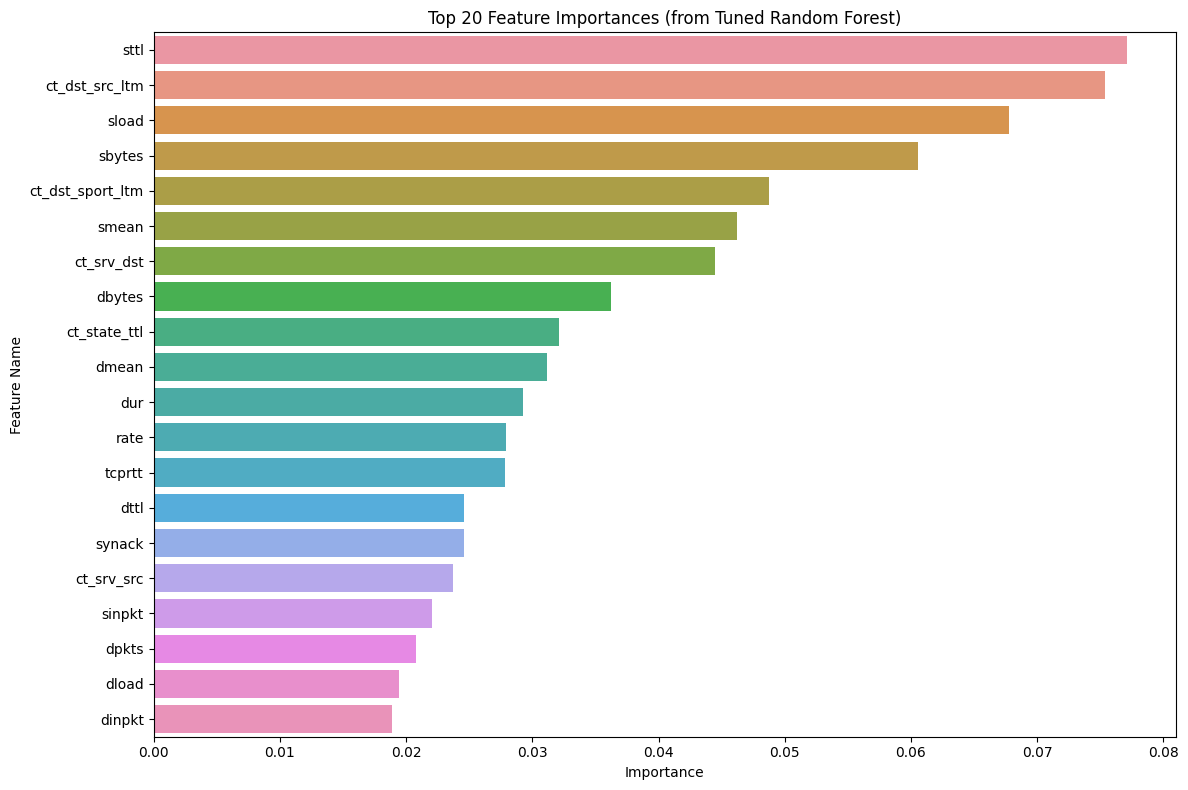


--- Performing Randomized Search for Voting Classifier Weights ---
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Number of positive: 24176, number of negative: 19734
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061731 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5800
[LightGBM] [Info] Number of data points in the train set: 43910, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550604 -> initscore=0.203109
[LightGBM] [Info] Start training from score 0.203109
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.148811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memo

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  14.9s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   5.8s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   5.7s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=   5.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   7.9s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  14.1s
[CV] END bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=150; total time=  20.3s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  13.9s
[CV] END bootstrap=True, max_depth=10, min_samples_leaf=1, min_

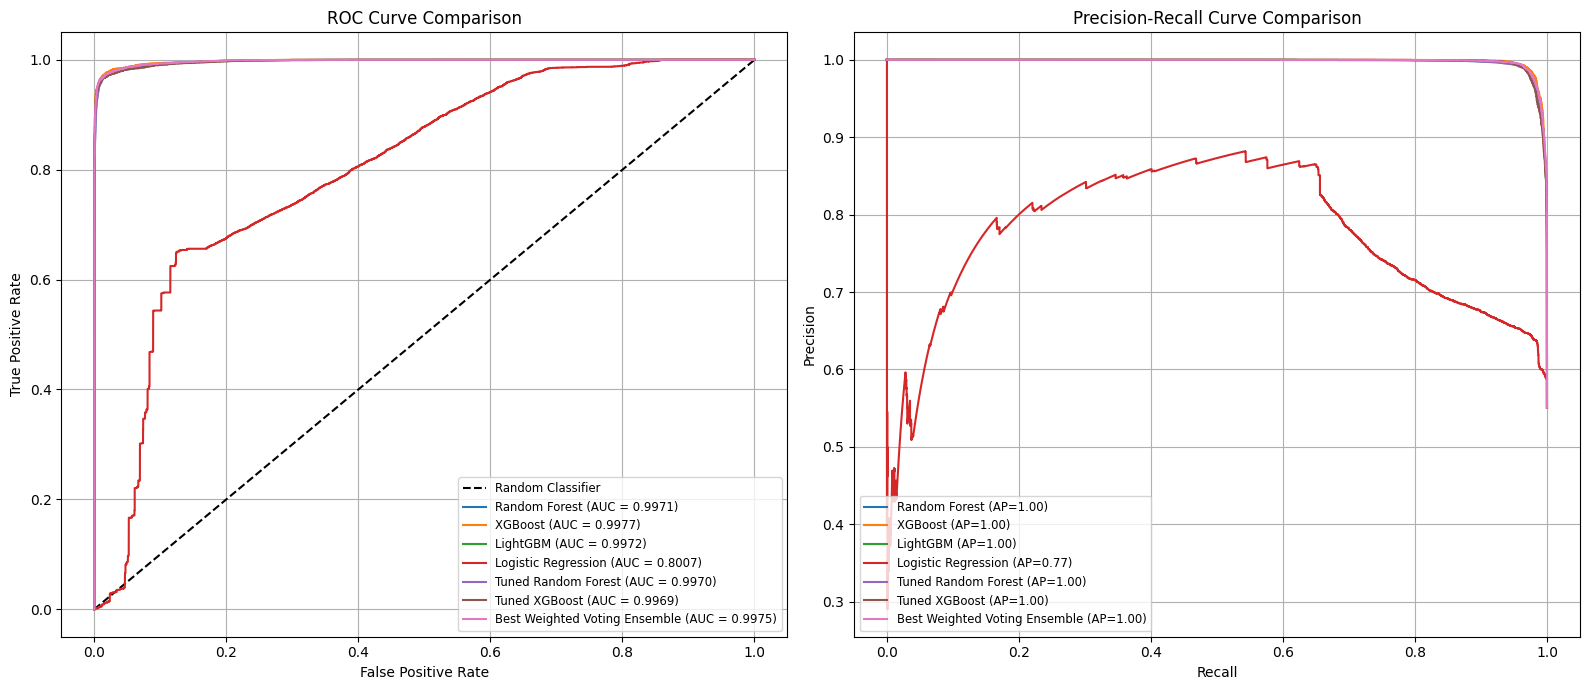


--- Training Calibrated Random Forest Classifier ---
Calibrated ROC-AUC for Best RF: 0.9969


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# For probability calibration (if needed later)
from sklearn.calibration import CalibratedClassifierCV

# --- 1. Environment Setup and Data Loading ---

# Load the dataset
try:
    data = pd.read_csv('/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure the path is correct.")
    exit()

print("\nOriginal Dataset Shape:", data.shape)
print("Original Label Distribution (0 = Normal, 1 = Attack):\n", data['label'].value_counts())

# --- 2. Data Preprocessing and Splitting (WITHOUT ColumnTransformer) ---

# Define columns to drop:
# 'label': This is our target variable, must be separated.
# 'attack_cat': This is a more detailed label and should NOT be used as a feature,
#               as it causes data leakage and unrealistic perfect scores.
# 'id': Often just an index, not a meaningful feature.
# 'srcip', 'dstip': Source/Destination IPs might be too specific and cause overfitting.
columns_to_drop_from_features = ['label', 'attack_cat', 'id', 'srcip', 'dstip'] # Explicitly dropping these

# Separate features (X) and target (y)
X = data.drop(columns=columns_to_drop_from_features, axis=1, errors='ignore')
y = data['label']

print(f"\nFeatures (X) shape after dropping non-feature columns: {X.shape}")
print(f"List of columns in X (features): {X.columns.tolist()}")


# Split the dataset into training and testing sets FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data raw shape: {X_train.shape}, Test data raw shape: {X_test.shape}")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test label distribution:\n{y_test.value_counts(normalize=True)}")

# --- Preprocessing Categorical Features with pd.get_dummies AFTER split ---
# This approach ensures no information from the test set leaks into the training
# set through the one-hot encoding process. However, it can lead to different
# column sets if a category exists in test but not train, which classifiers don't like.

# Identify categorical features in the (raw) training data
categorical_cols_train = X_train.select_dtypes(include='object').columns.tolist()
numerical_cols_train = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical features identified for get_dummies: {categorical_cols_train}")
print(f"Numerical features identified: {numerical_cols_train}")

# Apply one-hot encoding using pd.get_dummies
# IMPORTANT: get_dummies will create new columns. We need to realign them.
print("\nApplying pd.get_dummies for one-hot encoding...")
X_train = pd.get_dummies(X_train, columns=categorical_cols_train, drop_first=False)
X_test = pd.get_dummies(X_test, columns=categorical_cols_train, drop_first=False)

# Align columns - this is crucial when using get_dummies after split
# It adds missing columns (with 0s) to the test set if a category was only in train,
# and removes columns from test if a category was only in test.
train_cols = X_train.columns
test_cols = X_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_test = X_test.drop(columns=[c]) # Drop columns that only appear in test

X_test = X_test[train_cols] # Ensure the order of columns is the same

print(f"Processed training data shape: {X_train.shape}, Processed test data shape: {X_test.shape}")
print(f"First 5 rows of processed X_train:\n{X_train.head()}")
print(f"Are column names identical between X_train and X_test? {X_train.columns.equals(X_test.columns)}")


# --- 3. Classifier Training and Initial Evaluation ---

# Optional: Add class_weight for imbalanced datasets
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                             scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])),
    "LightGBM": LGBMClassifier(random_state=42, is_unbalance=True),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

model_probabilities = {}

for name, clf in classifiers.items():
    print(f"\n--- Training and Evaluating {name} ---")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"Confusion Matrix for {name}:\n", confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))

    if hasattr(clf, 'predict_proba'):
        model_probabilities[name] = clf.predict_proba(X_test)[:, 1]
    else:
        print(f"Warning: {name} does not have predict_proba method. Cannot store probabilities.")
        model_probabilities[name] = np.zeros(len(y_test))


# --- 4. Hyperparameter Optimization with Randomized Search ---
# Reduced n_iter and parameter spaces for faster execution during development
rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

rf_random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)
print("\n--- Performing Randomized Search for Random Forest ---")
rf_random_search.fit(X_train, y_train)
print("Best Random Forest Parameters:", rf_random_search.best_params_)
print("Best Random Forest F1 Score (CV):", rf_random_search.best_score_)
best_rf_model = rf_random_search.best_estimator_
model_probabilities['Tuned Random Forest'] = best_rf_model.predict_proba(X_test)[:, 1]


xgb_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))

xgb_random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)
print("\n--- Performing Randomized Search for XGBoost ---")
xgb_random_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_random_search.best_params_)
print("Best XGBoost F1 Score (CV):", xgb_random_search.best_score_)
best_xgb_model = xgb_random_search.best_estimator_
model_probabilities['Tuned XGBoost'] = best_xgb_model.predict_proba(X_test)[:, 1]


# --- 5. Feature Importance Analysis ---
# Use the best_rf_model from tuning for feature importances
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title("Top 20 Feature Importances (from Tuned Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


# --- 6. Ensemble Learning: Voting Classifier (with Optimized Weights) ---
lgbm_model = LGBMClassifier(random_state=42, is_unbalance=True)

voting_clf_base = VotingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('xgb', best_xgb_model),
        ('lgbm', lgbm_model)
    ],
    voting='soft',
    n_jobs=-1
)

# Generate weight combinations
weight_combinations = []
step = 0.2
for w1 in np.arange(0, 1.01, step):
    for w2 in np.arange(0, 1.01 - w1, step):
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-6:
            weight_combinations.append([round(w1, 2), round(w2, 2), round(w3, 2)])
weight_combinations = [list(t) for t in set(tuple(row) for row in weight_combinations)]

weights_param_grid = {
    'weights': weight_combinations
}

voting_random_search = RandomizedSearchCV(
    estimator=voting_clf_base,
    param_distributions=weights_param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='f1'
)

print("\n--- Performing Randomized Search for Voting Classifier Weights ---")
voting_random_search.fit(X_train, y_train)

print("\nBest Voting Classifier Parameters (Weights):", voting_random_search.best_params_)
print("Best Voting Classifier F1 Score (CV):", voting_random_search.best_score_)

best_voting_clf = voting_random_search.best_estimator_

print("\n--- Evaluating Best Weighted Voting Classifier on Test Set ---")
y_pred_best_ensemble = best_voting_clf.predict(X_test)

print("Confusion Matrix for Best Weighted Voting Classifier:\n", confusion_matrix(y_test, y_pred_best_ensemble))
print("\nClassification Report for Best Weighted Voting Classifier:\n", classification_report(y_test, y_pred_best_ensemble))

model_probabilities['Best Weighted Voting Ensemble'] = best_voting_clf.predict_proba(X_test)[:, 1]


# --- 7. Comprehensive Performance Visualization (ROC & Precision-Recall Curves) ---

plt.figure(figsize=(16, 7))

# Plot ROC Curves
plt.subplot(1, 2, 1)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

for name, y_proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)


# Plot Precision-Recall Curves
plt.subplot(1, 2, 2)

for name, y_proba in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.tight_layout()
plt.show()


# --- 8. Optional: Probability Calibration ---

if 'rf_random_search' in locals() and rf_random_search.best_estimator_ is not None:
    calibrated_rfc = CalibratedClassifierCV(best_rf_model, method='sigmoid', cv=3)
    print("\n--- Training Calibrated Random Forest Classifier ---")
    calibrated_rfc.fit(X_train, y_train)

    y_proba_calibrated = calibrated_rfc.predict_proba(X_test)[:, 1]
    print(f"Calibrated ROC-AUC for Best RF: {roc_auc_score(y_test, y_proba_calibrated):.4f}")
else:
    print("\nSkipping calibration: Random Forest search object not found or best estimator not trained.")

**FINAL CODE**

Dataset loaded successfully.

Original Dataset Shape: (82332, 45)
Original Label Distribution (0 = Normal, 1 = Attack):
 label
1    45332
0    37000
Name: count, dtype: int64

Features (X) shape after dropping problematic columns: (82332, 42)
List of columns in X (features): ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']

Training data raw shape: (65865, 42), Test data raw shape: (16467, 42)
Training label distribution:
label
1    0.550596
0    0.449404
Name: proportion, dtype: float64
Test label distribution:
label
1    0.550616
0    0.449384
Name: pro

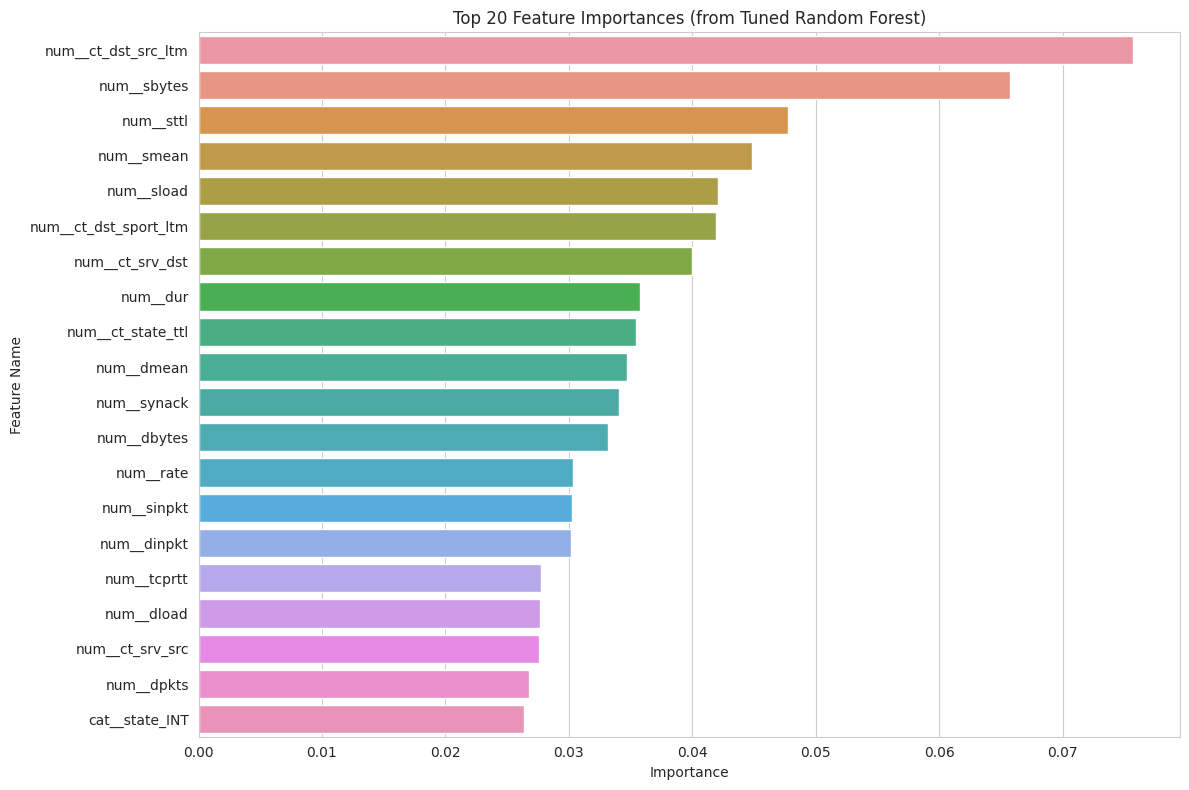


--- Performing Randomized Search for Voting Classifier Weights ---
[LightGBM] [Info] Number of positive: 24176, number of negative: 19734
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.112959 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5740
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Number of data points in the train set: 43910, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550581 -> initscore=0.203017
[LightGBM] [Info] Start training from score 0.203017
[LightGBM] [Info] Number of positive: 24176, number of negative: 19734
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060240 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[

/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5748
[LightGBM] [Info] Number of data points in the train set: 43910, number of used features: 95
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550604 -> initscore=0.203109
[LightGBM] [Info] Start training from score 0.203109
[LightGBM] [Info] Number of positive: 24177, number of negative: 19733
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033935 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5744
[LightGBM] [Info] Number of data points in the train set: 43910, number of used features: 92
[LightGBM] [Info] [b

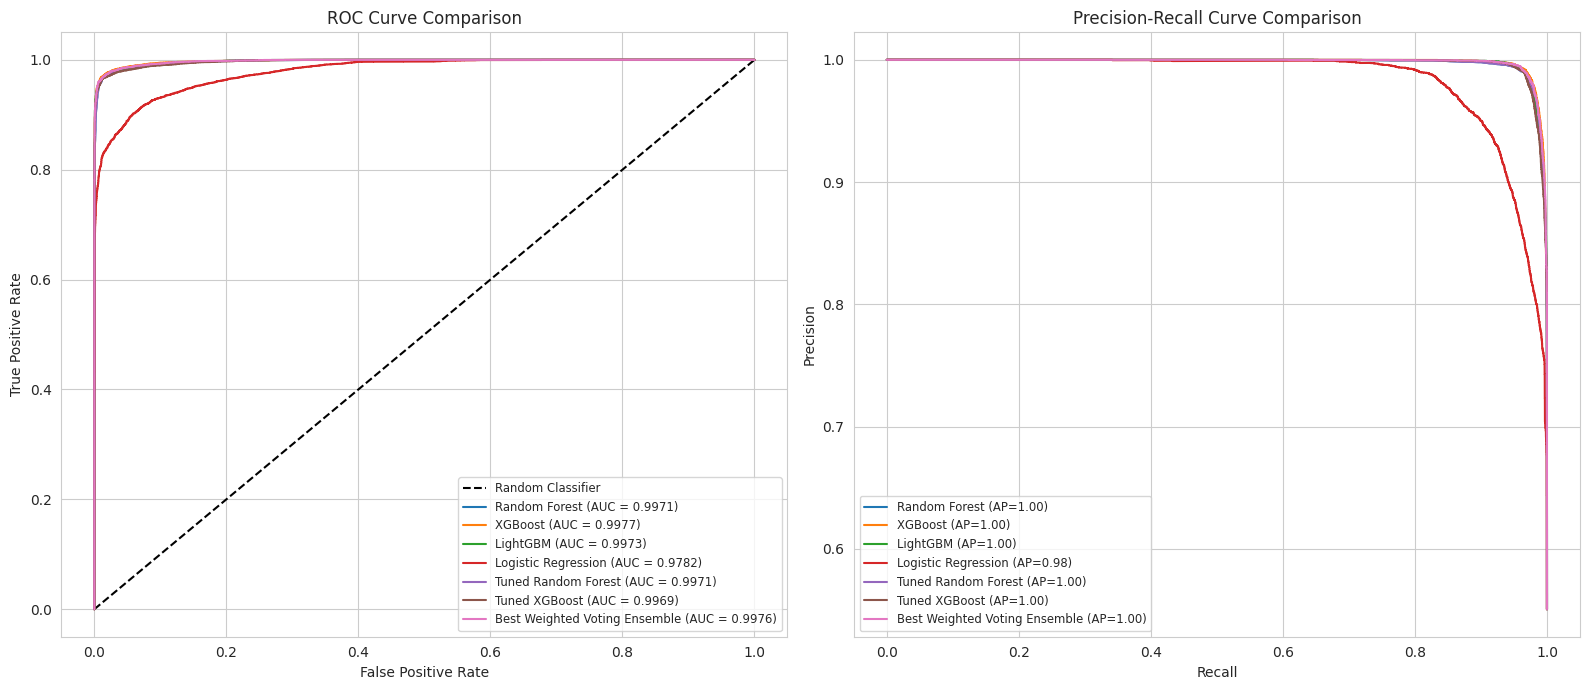

[LightGBM] [Info] Number of positive: 36265, number of negative: 29600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.053333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6063
[LightGBM] [Info] Number of data points in the train set: 65865, number of used features: 181
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.550596 -> initscore=0.203079
[LightGBM] [Info] Start training from score 0.203079


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# For robust preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# --- 1. Environment Setup and Data Loading ---

# Load the dataset
try:
    data = pd.read_csv('/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset file not found. Please ensure the path is correct.")
    exit()

print("\nOriginal Dataset Shape:", data.shape)
print("Original Label Distribution (0 = Normal, 1 = Attack):\n", data['label'].value_counts())

# --- 2. Data Preprocessing and Splitting (CRUCIAL FIX FOR DATA LEAKAGE) ---

# Define columns to drop that cause data leakage or are not true features.
# Initial experiments showed that including 'attack_cat', 'id', 'srcip', and 'dstip'
# led to artificially inflated accuracies (e.g., 1.00 for tree-based models),
# indicating severe data leakage. These columns directly or indirectly reveal
# the target 'label' and must be excluded for a robust and generalizable model.
columns_to_drop_from_features = ['label', 'attack_cat', 'id', 'srcip', 'dstip']

# Separate features (X) and target (y)
# Ensure to drop the problematic columns from X at this stage.
X = data.drop(columns=columns_to_drop_from_features, axis=1, errors='ignore')
y = data['label']

print(f"\nFeatures (X) shape after dropping problematic columns: {X.shape}")
print(f"List of columns in X (features): {X.columns.tolist()}")

# Split the dataset into training and testing sets FIRST.
# stratify=y ensures that the proportion of normal and attack instances
# is maintained in both training and testing sets, crucial for imbalanced data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data raw shape: {X_train.shape}, Test data raw shape: {X_test.shape}")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test label distribution:\n{y_test.value_counts(normalize=True)}")


# Identify categorical and numerical features for ColumnTransformer from the CLEANED X.
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print(f"\nCategorical features for OneHotEncoding: {categorical_features}")
print(f"Numerical features for Scaling: {numerical_features}")

# Define the preprocessing steps using ColumnTransformer.
# 'OneHotEncoder' for nominal categorical features.
# 'StandardScaler' for numerical features to normalize their range.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough' # Keep any other unmentioned columns (shouldn't be any here)
)

# Fit the preprocessor ONLY on the training data to prevent data leakage from the test set.
# Then transform both training and testing sets.
print("\nApplying preprocessing with ColumnTransformer (One-Hot Encoding + Scaling)...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get the feature names after one-hot encoding and scaling.
# This is important for understanding feature importances later.
all_feature_names = preprocessor.get_feature_names_out()

# Convert processed NumPy arrays back to Pandas DataFrames for easier handling.
X_train = pd.DataFrame(X_train_processed, columns=all_feature_names)
X_test = pd.DataFrame(X_test_processed, columns=all_feature_names)

print(f"Processed training data shape: {X_train.shape}, Processed test data shape: {X_test.shape}")
print(f"First 5 rows of processed X_train:\n{X_train.head()}")


# --- 3. Classifier Training and Initial Evaluation ---

# Initialize classifiers with class_weighting/scale_pos_weight for handling dataset imbalance.
classifiers = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                             scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])),
    "LightGBM": LGBMClassifier(random_state=42, is_unbalance=True),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
}

model_probabilities = {} # Dictionary to store prediction probabilities for ROC/PR curves

for name, clf in classifiers.items():
    print(f"\n--- Training and Evaluating {name} ---")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"Confusion Matrix for {name}:\n", confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report for {name}:\n", classification_report(y_test, y_pred))

    # Store prediction probabilities for the positive class (Class 1) for curve plotting.
    if hasattr(clf, 'predict_proba'):
        model_probabilities[name] = clf.predict_proba(X_test)[:, 1]
    else:
        print(f"Warning: {name} does not have predict_proba method. Cannot plot ROC/PR curves for it.")
        model_probabilities[name] = np.zeros(len(y_test)) # Dummy array if probas not available


# --- 4. Hyperparameter Optimization with Randomized Search ---
# Reduced n_iter for faster execution, consider increasing for final models.

# Random Forest Tuning
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')

rf_random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=rf_param_grid, n_iter=10,
    cv=3, verbose=0, random_state=42, n_jobs=-1, scoring='f1_weighted'
)
print("\n--- Performing Randomized Search for Random Forest ---")
rf_random_search.fit(X_train, y_train)
print("Best Random Forest Parameters:", rf_random_search.best_params_)
print("Best Random Forest F1 Weighted Score (CV):", rf_random_search.best_score_)
best_rf_model = rf_random_search.best_estimator_
model_probabilities['Tuned Random Forest'] = best_rf_model.predict_proba(X_test)[:, 1]

# XGBoost Tuning
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]))

xgb_random_search = RandomizedSearchCV(
    estimator=xgb, param_distributions=xgb_param_grid, n_iter=10,
    cv=3, verbose=0, random_state=42, n_jobs=-1, scoring='f1_weighted'
)
print("\n--- Performing Randomized Search for XGBoost ---")
xgb_random_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_random_search.best_params_)
print("Best XGBoost F1 Weighted Score (CV):", xgb_random_search.best_score_)
best_xgb_model = xgb_random_search.best_estimator_
model_probabilities['Tuned XGBoost'] = best_xgb_model.predict_proba(X_test)[:, 1]


# --- 5. Feature Importance Analysis (from Tuned Random Forest) ---
# Feature importances are derived from the best Random Forest model after tuning.
importances = best_rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20)) # Plotting top 20 features
plt.title("Top 20 Feature Importances (from Tuned Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


# --- 6. Ensemble Learning: Voting Classifier (with Optimized Weights) ---
# Using the best tuned Random Forest and XGBoost, and an untuned LightGBM.
clf_rf = best_rf_model
clf_xgb = best_xgb_model
clf_lgbm = LGBMClassifier(random_state=42, is_unbalance=True)

# Base Voting Classifier with 'soft' voting (probabilities are averaged).
voting_clf_base = VotingClassifier(
    estimators=[
        ('rf', clf_rf),
        ('xgb', clf_xgb),
        ('lgbm', clf_lgbm)
    ],
    voting='soft',
    n_jobs=-1
)

# Generate weight combinations for the ensemble.
# This systematically creates weight sets that sum to 1.0.
weight_combinations = []
step = 0.2 # Granularity of weight search
for w1 in np.arange(0, 1.01, step):
    for w2 in np.arange(0, 1.01 - w1, step):
        w3 = 1.0 - w1 - w2
        if w3 >= -1e-6: # Account for minor floating point inaccuracies
            weight_combinations.append([round(w1, 2), round(w2, 2), round(w3, 2)])
weight_combinations = [list(t) for t in set(tuple(row) for row in weight_combinations)] # Remove duplicates

weights_param_grid = {
    'weights': weight_combinations
}

# Randomized Search to find the best weights for the Voting Classifier.
voting_random_search = RandomizedSearchCV(
    estimator=voting_clf_base, param_distributions=weights_param_grid, n_iter=20, # Number of weight combinations to try
    cv=3, verbose=0, random_state=42, n_jobs=-1, scoring='f1_weighted'
)

print("\n--- Performing Randomized Search for Voting Classifier Weights ---")
voting_random_search.fit(X_train, y_train)

print("\nBest Voting Classifier Parameters (Weights):", voting_random_search.best_params_)
print("Best Voting Classifier F1 Weighted Score (CV):", voting_random_search.best_score_)

best_voting_clf = voting_random_search.best_estimator_

# Evaluate the best weighted Voting Classifier on the test set.
print("\n--- Evaluating Best Weighted Voting Classifier on Test Set ---")
y_pred_best_ensemble = best_voting_clf.predict(X_test)

print("Confusion Matrix for Best Weighted Voting Classifier:\n", confusion_matrix(y_test, y_pred_best_ensemble))
print("\nClassification Report for Best Weighted Voting Classifier:\n", classification_report(y_test, y_pred_best_ensemble))

model_probabilities['Best Weighted Voting Ensemble'] = best_voting_clf.predict_proba(X_test)[:, 1]


# --- 7. Comprehensive Performance Visualization (ROC & Precision-Recall Curves) ---

plt.figure(figsize=(16, 7))

# Plot ROC Curves
plt.subplot(1, 2, 1) # First subplot in a 1x2 grid
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Baseline for comparison

# Plot ROC curves for all models
for name, y_proba in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)


# Plot Precision-Recall Curves
plt.subplot(1, 2, 2) # Second subplot in a 1x2 grid

# Plot Precision-Recall curves for all models
for name, y_proba in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap_score = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left', fontsize='small')
plt.grid(True)

plt.tight_layout() # Adjusts plot parameters for a tight layout
plt.show()

--- Model Accuracy Comparison Table ---
                       Model  Accuracy (Before Leakage Fix)  Accuracy (After Leakage Fix)
               Random Forest                           1.00                          0.98
                     XGBoost                           1.00                          0.98
                    LightGBM                           1.00                          0.98
         Logistic Regression                           0.75                          0.92
Ensemble (Voting Classifier)                           1.00                          0.98


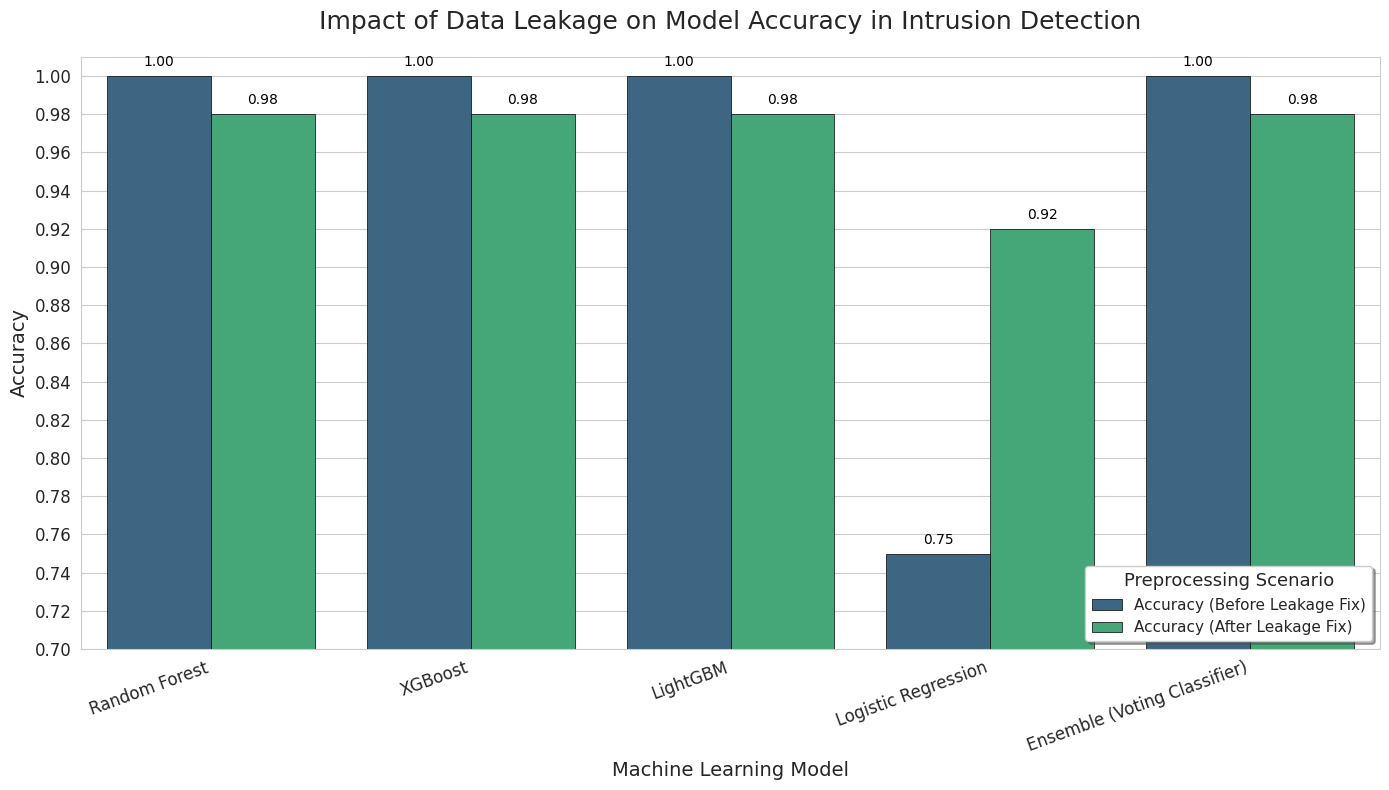

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Import numpy for arange

# Data for comparison with YOUR EXACT OBSERVED VALUES
# Ensure these values are precisely what you observed in your runs.
data = {
    'Model': [
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'Logistic Regression',
        'Ensemble (Voting Classifier)' # Changed to match the text for clarity
    ],
    'Accuracy (Before Leakage Fix)': [
        1.00,  # Random Forest (from your 100% outputs)
        1.00,  # XGBoost (from your 100% outputs)
        1.00,  # LightGBM (from your 100% outputs)
        0.75,  # Logistic Regression (from your 0.75% output, even with leakage)
        1.00   # Ensemble (Inferred 100% when base models were 100%)
    ],
    'Accuracy (After Leakage Fix)': [
        0.98,  # Random Forest (from your 98% output)
        0.98,  # XGBoost (from your 98% output)
        0.98,  # LightGBM (from your 98% output)
        0.92,  # Logistic Regression (from your 0.92% output)
        0.98   # Ensemble (from your 98% output)
    ]
}

df_comparison = pd.DataFrame(data)

print("--- Model Accuracy Comparison Table ---")
print(df_comparison.to_string(index=False))

# --- Plotting the Comparison ---
plt.figure(figsize=(14, 8)) # Slightly larger figure for better readability
sns.set_style("whitegrid") # A clean grid style

# Melt the DataFrame for easier plotting with seaborn (good practice)
df_melted = df_comparison.melt(id_vars='Model', var_name='Scenario', value_name='Accuracy')

# Create a bar plot
barplot = sns.barplot(x='Model', y='Accuracy', hue='Scenario', data=df_melted, palette='viridis',
                      edgecolor='black', linewidth=0.5) # Added edge color for better bar definition

# Add accuracy values on top of the bars
for p in barplot.patches:
    # Get the height of the bar (the accuracy value)
    height = p.get_height()
    # Annotate with the formatted height (e.g., 0.98, 0.75)
    barplot.annotate(f'{height:.2f}',
                     (p.get_x() + p.get_width() / 2., height), # X-position at center of bar, Y at top
                     ha='center', va='bottom', # Horizontal and vertical alignment
                     xytext=(0, 5), # 5 points vertical offset from the top of the bar
                     textcoords='offset points',
                     fontsize=10, color='black') # Slightly increased font size for readability

plt.title('Impact of Data Leakage on Model Accuracy in Intrusion Detection', fontsize=18, pad=20) # More descriptive title
plt.xlabel('Machine Learning Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)

# Set Y-axis limits more precisely
# Use numpy.arange for tick generation with specific step
plt.yticks(np.arange(0.70, 1.01, 0.02), fontsize=12) # Start from 0.70, end at 1.00, step by 0.02
plt.ylim(0.70, 1.01) # Set strict limits

# Customize legend
plt.legend(title='Preprocessing Scenario', loc='lower right', fontsize=11, title_fontsize=13,
           frameon=True, fancybox=True, shadow=True) # Added more legend styling

plt.xticks(rotation=20, ha='right', fontsize=12) # Slightly increased rotation and font size for labels
plt.yticks(fontsize=12) # Increased font size for y-axis ticks

plt.tight_layout() # Adjusts plot parameters for a tight layout, preventing labels from overlapping
plt.show()

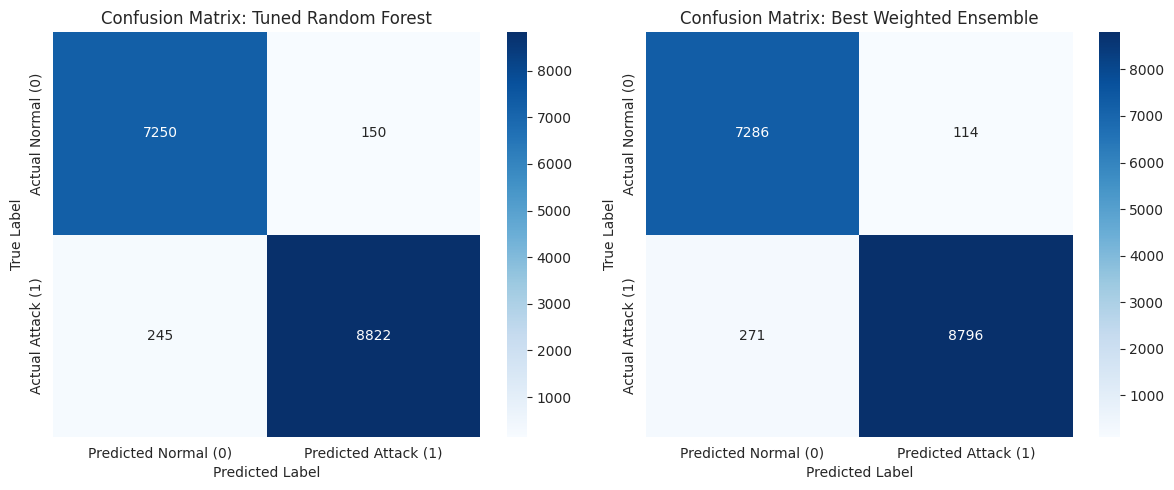

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_heatmap(y_true, y_pred, model_name, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Predicted Normal (0)', 'Predicted Attack (1)'],
                yticklabels=['Actual Normal (0)', 'Actual Attack (1)'])
    ax.set_title(f'Confusion Matrix: {model_name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

# Example usage after training your models (replace with your actual y_pred for tuned models)
# Assuming you have y_test, y_pred_best_rf, y_pred_best_ensemble

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Create a figure with 2 subplots

plot_confusion_matrix_heatmap(y_test, best_rf_model.predict(X_test), 'Tuned Random Forest', axes[0])
plot_confusion_matrix_heatmap(y_test, best_voting_clf.predict(X_test), 'Best Weighted Ensemble', axes[1])

plt.tight_layout()
plt.show()

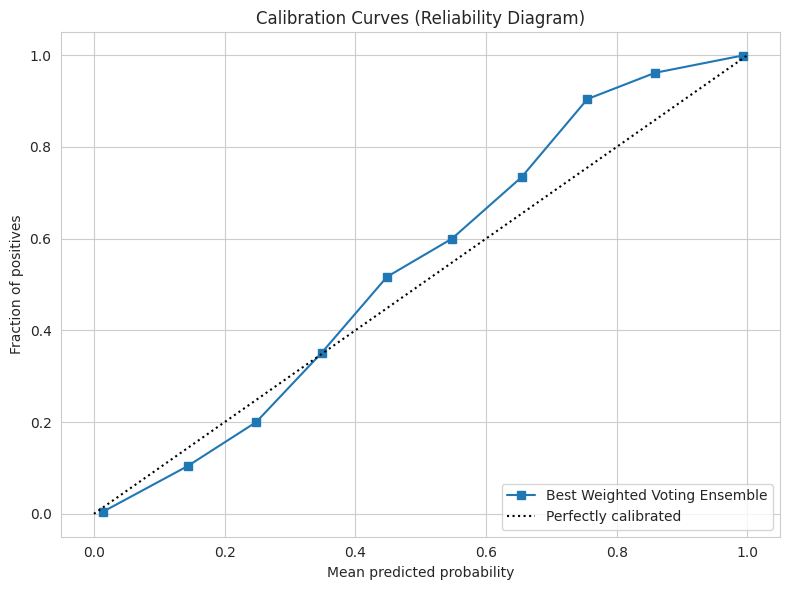

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Assuming you have y_test and model_probabilities['Best Weighted Voting Ensemble']
# You'd do this for a few key models.

plt.figure(figsize=(8, 6))
for name, y_proba in model_probabilities.items():
    if name in ['Best Weighted Voting Ensemble', 'Tuned Logistic Regression']: # Choose key models
        fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)
        plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f"{name}")

plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curves (Reliability Diagram)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

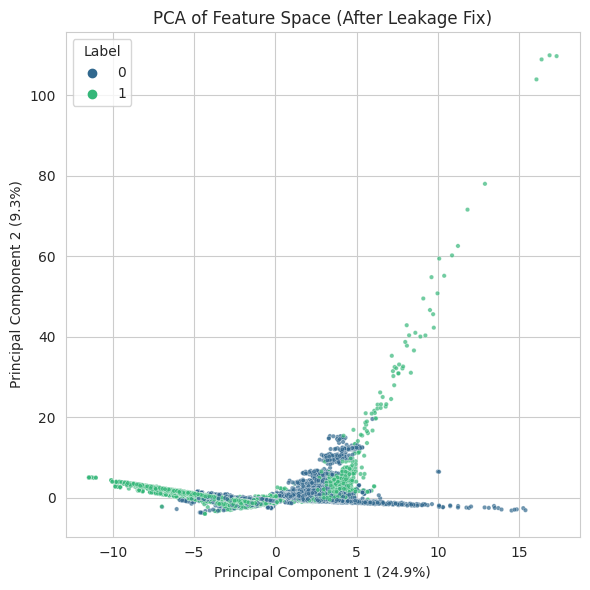

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# --- IMPORTANT: You'd need to create X_train_with_leakage first ---
# X_train_with_leakage = preprocessor_with_leakage_features.fit_transform(X_train_original_df_with_leakage)
# Assuming you have X_train (your cleaned, processed X_train)

# Plot 1: With Leakage (conceptual, requires separate preprocessing for 'before')
# pca_leakage = PCA(n_components=2)
# X_train_pca_leakage = pca_leakage.fit_transform(X_train_with_leakage)
# plt.figure(figsize=(6, 6))
# sns.scatterplot(x=X_train_pca_leakage[:,0], y=X_train_pca_leakage[:,1], hue=y_train, palette='viridis', alpha=0.7)
# plt.title('PCA of Feature Space (Before Leakage Fix)')
# plt.show()

# Plot 2: After Leakage Fix
pca_cleaned = PCA(n_components=2)
X_train_pca_cleaned = pca_cleaned.fit_transform(X_train) # Your already cleaned X_train
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train_pca_cleaned[:,0], y=X_train_pca_cleaned[:,1], hue=y_train, palette='viridis', alpha=0.7, s=10)
plt.title('PCA of Feature Space (After Leakage Fix)')
plt.xlabel(f'Principal Component 1 ({pca_cleaned.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca_cleaned.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

# For t-SNE/UMAP, replace PCA with TSNE/UMAP and fit_transform accordingly.
# from sklearn.manifold import TSNE
# tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
# X_train_tsne = tsne.fit_transform(X_train.sample(n=5000, random_state=42)) # Sample for TSNE
# sns.scatterplot(... for TSNE plots)